In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from keras import regularizers, Sequential, Input, layers
from keras.callbacks import EarlyStopping

I0000 00:00:1776785646.580416   12312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776785646.581021   12312 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776785646.681545   12312 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776785648.128105   12312 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Importing dataset

In [2]:
df_train = pd.read_csv('Marathon_dataset/train.csv')

In [3]:
df_train.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [4]:
df_train.columns

Index(['runner_id', 'age', 'gender', 'running_experience_months',
       'previous_marathon_count', 'training_program', 'motivation_level',
       'personal_best_minutes', 'weekly_mileage_km', 'weekly_mileage_miles',
       'runs_per_week', 'long_run_distance_km', 'speed_work_sessions_per_week',
       'rest_days_per_week', 'training_adherence_pct',
       'consecutive_weeks_no_miss', 'cross_training_hours_per_week',
       'resting_heart_rate_bpm', 'vo2_max', 'bmi', 'recovery_score',
       'sleep_hours_avg', 'injury_count', 'injury_severity', 'nutrition_score',
       'hydration_consistency', 'training_streak_days', 'missed_workout_pct',
       'early_morning_run_frequency', 'weather_condition_training_pct',
       'goal_completion_rate', 'run_club_attendance_rate',
       'warmup_adherence_pct', 'stretching_adherence_pct', 'marathon_date',
       'marathon_weather', 'course_difficulty', 'target_finish_time_minutes',
       'actual_finish_time_minutes', 'mental_preparation_score',
  

In [5]:
df_train = df_train.drop(columns=['runner_id', 'marathon_date'])

# Preprocessing

In [6]:
df_prep = df_train.copy()
df_prep.head()

,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,...,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,5,...,60,0,70,29,Hot,Mixed,254,297.0,5,0
1,43,Female,151,2,Advanced,1,196.0,20.0,12.4,5,...,64,0,94,0,Sunny,Mixed,201,231.0,7,1
2,32,Female,82,3,Advanced,6,211.0,23.1,14.4,6,...,81,54,47,39,Rainy,Flat,204,234.0,9,1
3,57,Male,6,0,Beginner,8,NaN,27.3,17.0,5,...,59,63,77,45,Sunny,Hilly,258,276.0,3,3
4,54,Female,11,0,Beginner,3,NaN,20.0,12.4,5,...,62,20,64,40,Cloudy,Mixed,245,296.0,8,0


In [7]:
df_prep = df_prep.drop_duplicates()
df_prep = df_prep.dropna(subset=['actual_finish_time_minutes'])


cols_median = ['personal_best_minutes', 'vo2_max', 'cross_training_hours_per_week']
for col in cols_median:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

cols_avg = ['sleep_hours_avg', 'nutrition_score', 'hydration_consistency']
for col in cols_avg:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mean())

df_prep['injury_severity'] = df_prep['injury_severity'].fillna(0)

In [8]:
(df_prep.isna().sum() / len(df_prep) * 100)[df_prep.isna().sum() > 0].round(2)

Series([], dtype: float64)

In [9]:
# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

df_prep['training_program'] = df_prep['training_program'].map(training_map)
df_prep['course_difficulty'] = df_prep['course_difficulty'].map(course_map)
df_prep['injury_severity'] = df_prep['injury_severity'].map(injury_map).fillna(0)

# 2. Nominal — one-hot on full df
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df_prep[['gender', 'marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(['gender', 'marathon_weather']),
                      index=df_prep.index)

df_prep = df_prep.drop(columns=['gender', 'marathon_weather'])
df_prep = pd.concat([df_prep, ohe_df], axis=1)

In [10]:
df_prep.head()

,age,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,runs_per_week,long_run_distance_km,...,actual_finish_time_minutes,mental_preparation_score,medal_outcome,gender_Male,gender_Non-binary,marathon_weather_Cold,marathon_weather_Hot,marathon_weather_Rainy,marathon_weather_Sunny,marathon_weather_Windy
0,25,48,0,2,4,261.0,20.0,12.4,5,15.0,...,297.0,5,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,43,151,2,3,1,196.0,20.0,12.4,5,15.0,...,231.0,7,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,32,82,3,3,6,211.0,23.1,14.4,6,15.0,...,234.0,9,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,57,6,0,1,8,261.0,27.3,17.0,5,15.0,...,276.0,3,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,54,11,0,1,3,261.0,20.0,12.4,5,15.0,...,296.0,8,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Separating X and y

In [49]:
df_clean = df_prep.copy()
df_prep = df_clean.copy()

In [50]:
minimum_drop_list = ["weekly_mileage_miles",
                     "target_finish_time_minutes",
                     "medal_outcome",
                     "personal_best_minutes",
                     'gender_Male',
                    'hydration_consistency',
                    'gender_Non-binary',
                    'bmi',
                    'previous_marathon_count',
                    'training_streak_days',
                    'training_adherence_pct',
                    'stretching_adherence_pct',
                    'mental_preparation_score',
                    'motivation_level',
                    'goal_completion_rate',
                    'warmup_adherence_pct',
                    'marathon_weather_Cold',
                    'marathon_weather_Rainy',
                    'marathon_weather_Windy',
                    'marathon_weather_Sunny',
                    'marathon_weather_Hot',
                    'weather_condition_training_pct',
                    'recovery_score']

In [51]:
df = df_prep.drop(columns=minimum_drop_list)

In [52]:
X = df.drop(columns=['actual_finish_time_minutes'])
y = df['actual_finish_time_minutes']

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating a Deeplearning Model

In [54]:
ss_scaler = StandardScaler()

In [55]:
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

In [56]:
model_dl = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(1)
])

/home/coren/.pyenv/versions/MarathonIQ/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model_dl.compile(optimizer='adam', loss='mae')

In [58]:
es = EarlyStopping(patience=5, restore_best_weights=True)
history = model_dl.fit(X_train_scaled,
                       y_train, epochs=50,
                       batch_size=32,
                       validation_split=0.2,
                       callbacks=[es])

Epoch 1/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 57.5964 - val_loss: 21.6614
Epoch 2/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 19.4384 - val_loss: 18.0105
Epoch 3/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 17.4198 - val_loss: 17.2823
Epoch 4/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 16.9247 - val_loss: 16.7410
Epoch 5/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 16.7303 - val_loss: 16.6682
Epoch 6/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 16.6535 - val_loss: 16.6664
Epoch 7/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 16.6407 - val_loss: 17.2755
Epoch 8/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 16.5999 - val_loss: 16.5523
Epoch 9/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 16.5914 - val_loss: 16.5014
Epoch 10/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 16.5600 - val_loss: 16.6307
Epoch 11/50
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 16.5235 - val_loss: 17.2567
Epoch 12

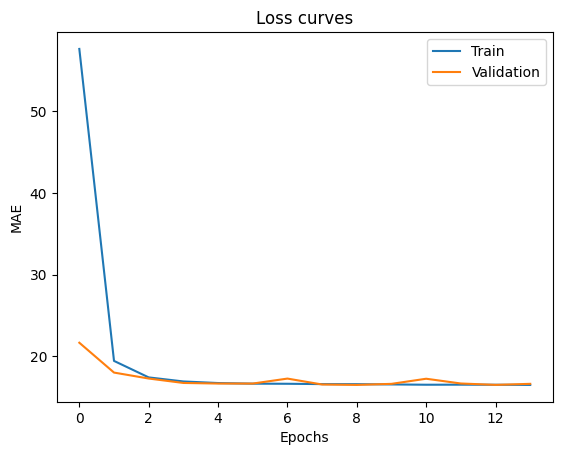

In [59]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss curves')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [60]:
y_pred = model_dl.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

488/488 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step
MAE:  16.53 minutes
RMSE: 20.65 minutes
R²:   0.6190


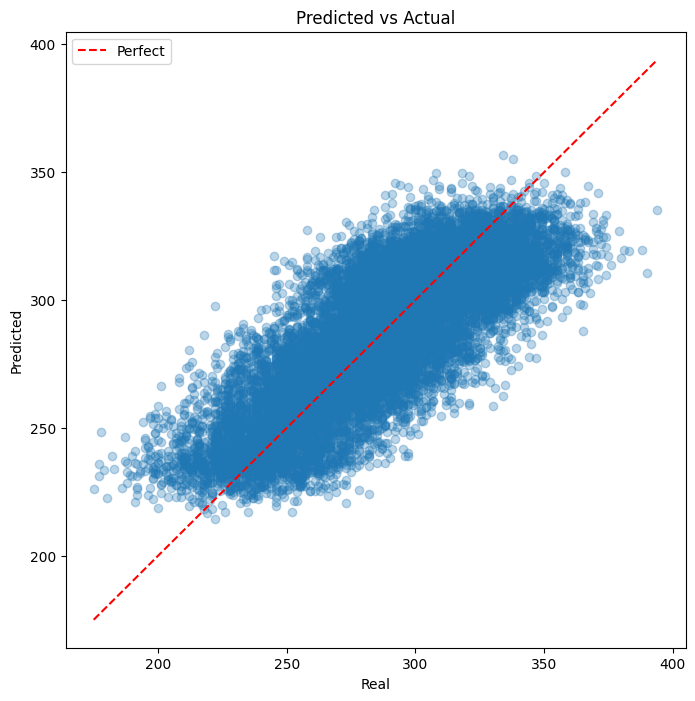

In [67]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect')
plt.xlabel('Real')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.legend()
plt.show()

# Testing it

In [110]:
df_test = pd.read_csv('Marathon_dataset/test.csv')

In [111]:
df_test = df_test.drop(columns=minimum_drop_list)
df_test = df_test.drop(columns=additional_drop)

KeyError: "['medal_outcome'] not found in axis"

In [ ]:
#X_real_test = df.drop(columns=['actual_finish_time_minutes'])
#y_real_test = df['actual_finish_time_minutes']

In [ ]:
#X_real_test_scaled = ss_scaler.transform(X_real_test)

#y_real_pred = model.predict(X_real_test_scaled)

#print(f"MAE:  {mean_absolute_error(y_real_test, y_real_pred):.2f} minutes")
#print(f"RMSE: {np.sqrt(mean_squared_error(y_real_test, y_real_pred)):.2f} minutes")
#print(f"R²:   {r2_score(y_real_test, y_real_pred):.4f}")